In [12]:
import json
import os

path = os.getcwd().split('/')[:-1]
filename = '/'.join(path) + '/dataset/response.json'

with open(filename, 'r') as f:
    real_data = json.load(f)

path = os.getcwd().split('/')[:-1]
filename = '/'.join(path) + '/dataset/drop-response-1.json'

with open(filename, 'r') as f:
    drop_data = json.load(f)

# path = os.getcwd().split('/')[:-1]
# filename = '/'.join(path) + '/dataset/sim-action-state-dataset.json'

# with open(filename, 'r') as f:
#     sim_data = json.load(f)


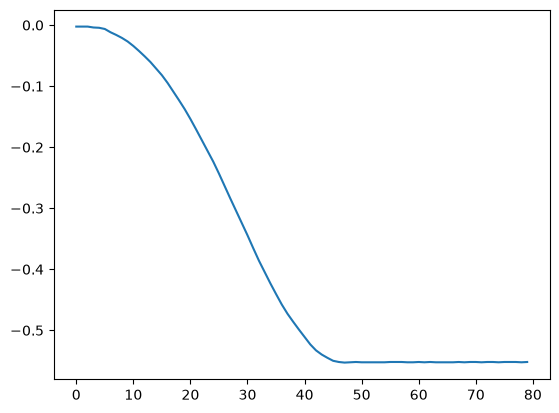

In [22]:
drop_data


import matplotlib.pyplot as plt
import numpy as np


# actions = np.array(drop_data['data'][0]['actions'])
states = np.array(drop_data['data'][0]['sensor_data'][100:180])

# plt.plot(actions)
plt.plot(states)

In [25]:
types = set()
for rollout in real_data['data']:
    types.add(rollout['type'])

print(types)


{'prbs', 'step', 'ramp', 'square', 'chirp', 'triangle'}


In [3]:
# def compute_loss(rollout_type, data1, data2):
#     for rollout1 in data1['data']:
#         if rollout1['type'] == rollout_type:
#             break

#     for rollout2 in data2['data']:
#         if rollout2['type'] == rollout_type:
#             break

#     sim_states = np.array(rollout1['sensor_data'])
#     real_states = np.array(rollout2['sensor_data'])
    
#     loss = np.mean(np.square(sim_states - real_states[:, 0]))

#     print(loss)

#     return sim_states, real_states



In [ ]:
for rollout in real_data['data']:
    print(rollout.keys())
    if rollout['type'] == 'step' and 'kv':
        plt.plot(rollout['sensor_data'])
plt.show()


dict_keys(['type', 'actions', 'sensor_data'])
dict_keys(['type', 'actions', 'sensor_data'])


KeyError: 'targets'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rollout(rollout_type, data):
    for rollout in data['data']:
        if rollout['type'] == rollout_type:
            break

    # actions = np.array(rollout['actions'])
    states = np.array(rollout['sensor_data'])

    # plt.plot(actions)
    plt.plot(states)


/var/folders/pb/2v43qld56svb17jrw__wt5mm0000gn/T/ipykernel_25833/95423082.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


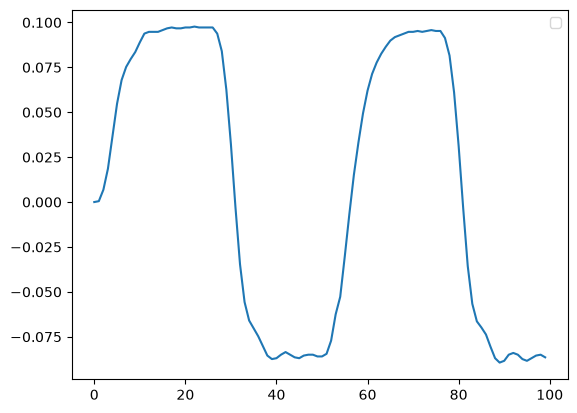

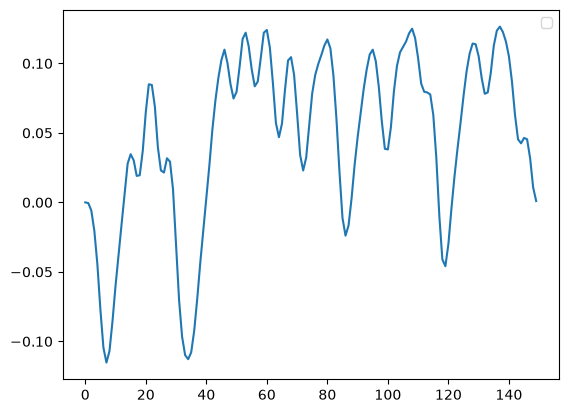

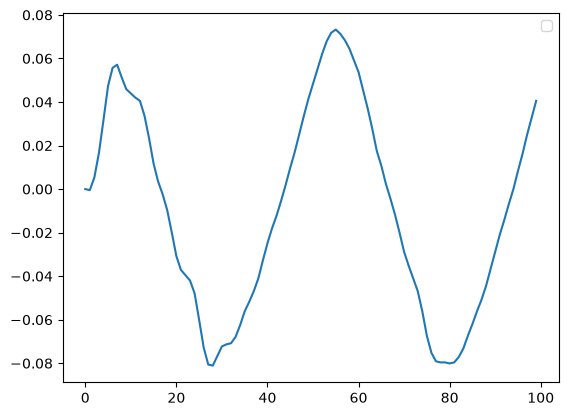

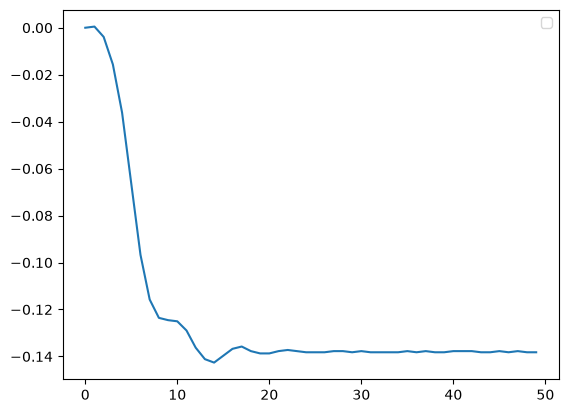

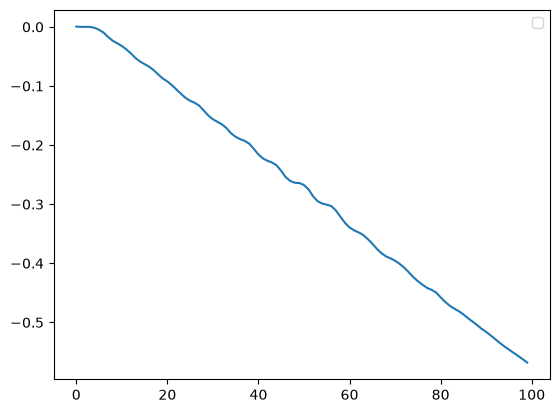

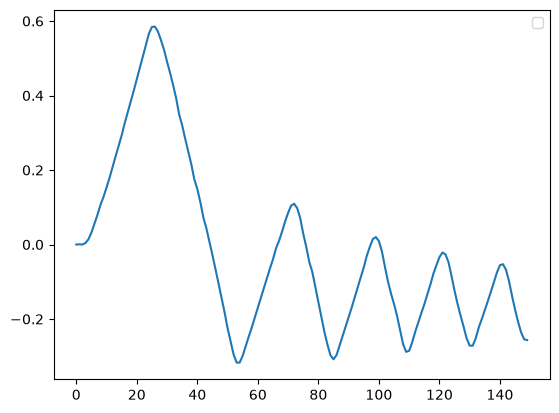

In [11]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    plot_rollout(key, real_data)
    plt.show()

6.907263005641152e-05


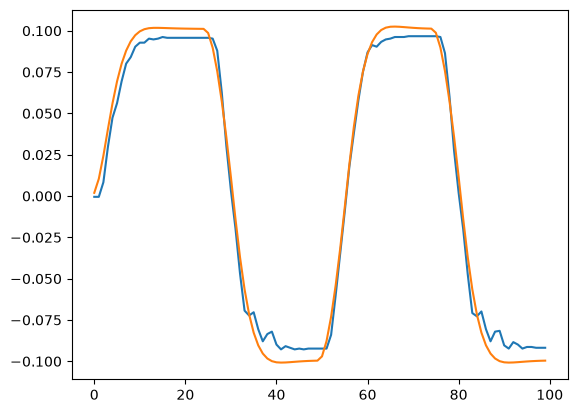

0.00046533341317805206


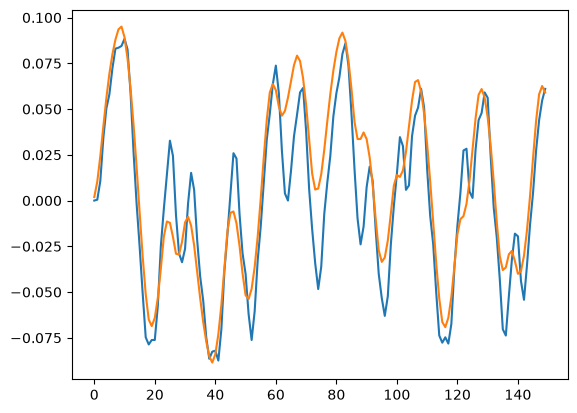

8.292675401648904e-05


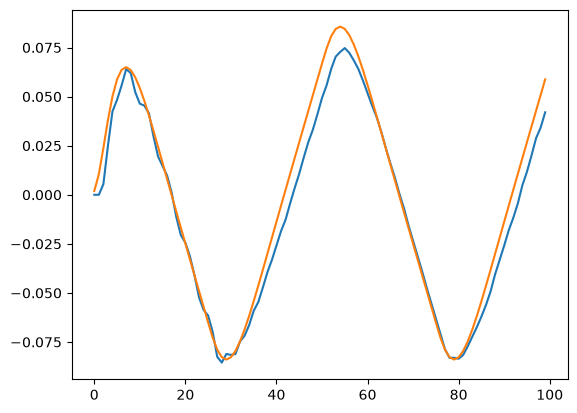

0.00023024535029023425


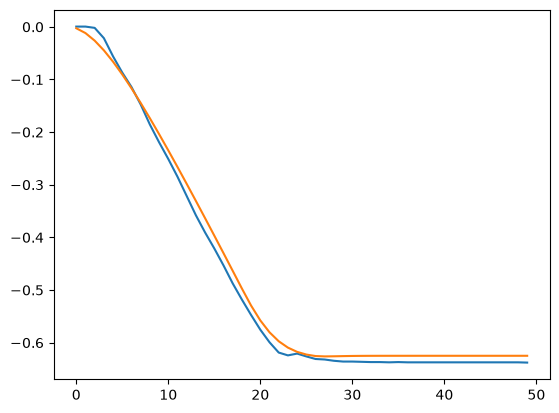

5.6151277250376464e-05


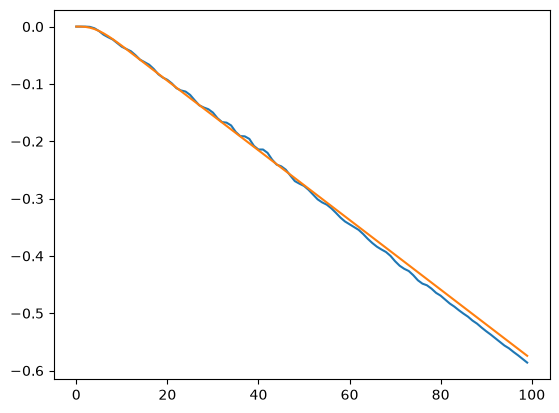

0.003961556890904894


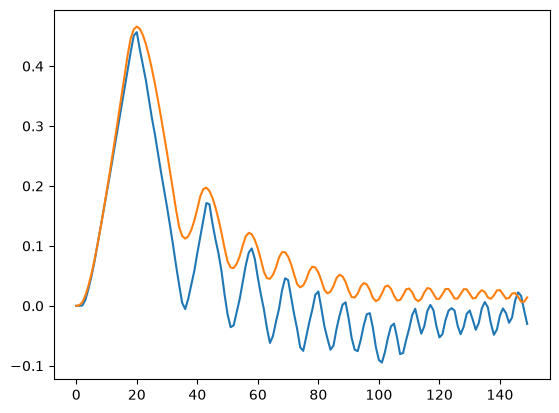

In [163]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    sim, real = compute_loss(key, real_data, sim_data)
    plt.plot(sim)
    plt.plot(real)
    plt.show()


# Original guessed values

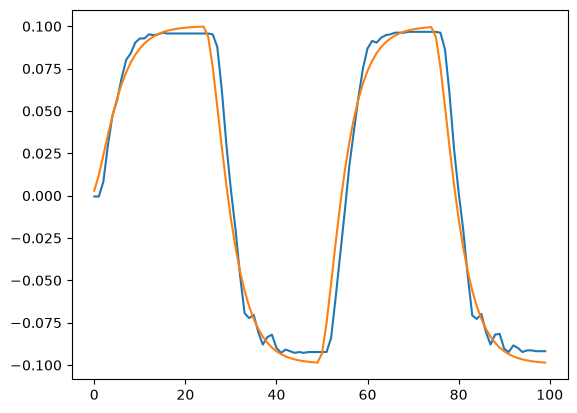

0.012916355954171474


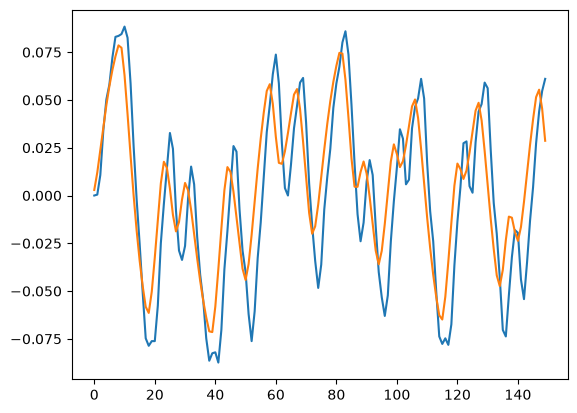

0.003522370841548391


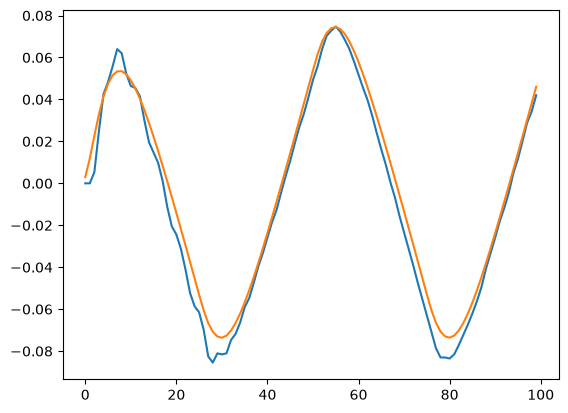

0.0045762328488400976


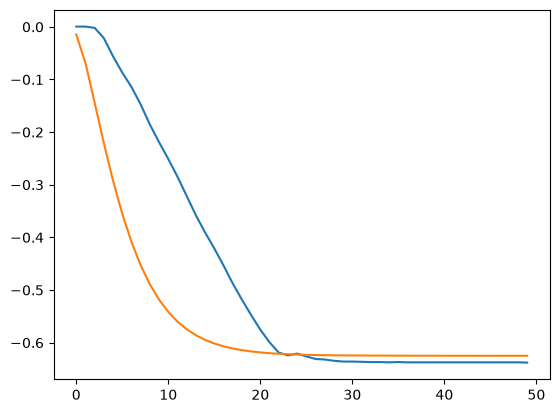

0.07752089045560451


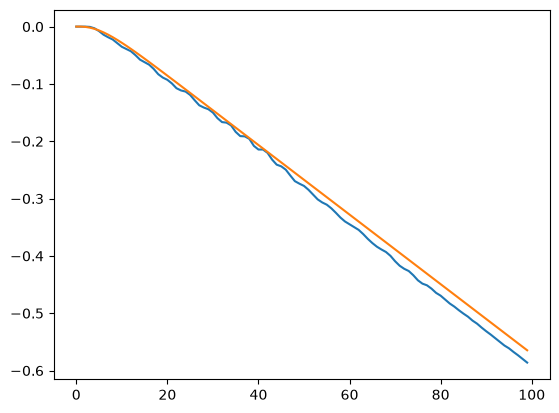

0.061967156448885


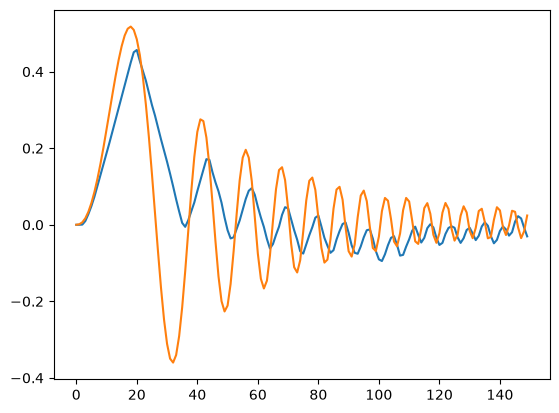

0.043918055856941224


In [91]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    plot_rollout(key, real_data)
    plot_rollout(key, sim_data)
    plt.show()
    compute_loss(key, real_data, sim_data)